In [35]:
import json
import numpy as np
from pathlib import Path
from typing import Iterable
import matplotlib.pyplot as plt

from itertools import chain
from pprint import pprint

In [36]:
def plot_confusion_matrix_binary(
    llm: Iterable[int | bool],
    human: Iterable[int | bool],
    title: str = "Confusion Matrix (LLM vs Human)",
    save_path: str | None = None,
) -> dict:
    """
    Compute and plot a confusion matrix for binary labels with FRACTIONS shown.

    Normalization:
      - Each cell shows fraction over ALL samples.
      - Also shows raw count in parentheses.

    Rows = Human labels (0, 1)
    Cols = LLM labels   (0, 1)

    Returns:
      dict with counts: TP, TN, FP, FN
    """
    llm = list(llm)
    human = list(human)

    if len(llm) != len(human):
        raise ValueError("Input arrays must have the same length.")

    TP = TN = FP = FN = 0
    for l, h in zip(llm, human):
        l = int(bool(l))
        h = int(bool(h))
        if l == 1 and h == 1:
            TP += 1
        elif l == 0 and h == 0:
            TN += 1
        elif l == 1 and h == 0:
            FP += 1
        elif l == 0 and h == 1:
            FN += 1

    total = TP + TN + FP + FN
    if total == 0:
        raise ValueError("No samples to plot.")

    # Confusion matrix (rows: human, cols: llm)
    cm_counts = [[TN, FP],
                 [FN, TP]]

    cm_frac = [[c / total for c in row] for row in cm_counts]

    # Plot
    plt.figure(figsize=(4.5, 4.5))
    plt.imshow(cm_frac)
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.xticks([0, 1], ["LLM = 0", "LLM = 1"])
    plt.yticks([0, 1], ["Human = 0", "Human = 1"])
    plt.xlabel("LLM Evaluation")
    plt.ylabel("Human Evaluation")
    plt.title(title)

    # Annotate cells with fraction + count
    for i in range(2):
        for j in range(2):
            frac = cm_frac[i][j]
            cnt = cm_counts[i][j]
            plt.text(
                j,
                i,
                f"{frac:.2f}\n({cnt})",
                ha="center",
                va="center",
                fontsize=11,
            )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)

    plt.show()

    return {"TP": TP, "TN": TN, "FP": FP, "FN": FN}

In [37]:
def load_evals(run_dir, entry_list, summary_filename="summary.json"):
    run_dir = Path(run_dir).expanduser().resolve()
    summary_path = run_dir / summary_filename

    data = json.loads(summary_path.read_text(encoding="utf-8"))
    tasks = data.get("tasks", [])

    # Initialize output dict with empty lists
    dict_out = {e: [] for e in entry_list}

    # Collect values from each task
    for t in tasks:
        for e in entry_list:
            if e in t:
                dict_out[e].append(t[e])
            else:
                dict_out[e].append(None)  # keeps alignment across tasks

    return dict_out

In [38]:
run_dir = r'G:\My Drive\Gkioxari_Lab\StateWMBench\StateWM\runs'
# runs = ['hunyuan_output_map_test_1', 'veo_output_map_test_1', 'wan22_output_map_test_1', "gt_final_frame_test_1"]
runs = ['hunyuan_output_map_test_1', 'veo_output_map_test_1', 'wan22_output_map_test_1',]

In [39]:
gemini_eval_entries = ['accuracy', 'camera_motion_done', 'trigger_applied']
dict_run_gemini_evals = {}

for r in runs:
    dict_run_gemini_evals.update({
        r: load_evals(f'{run_dir}\{r}', gemini_eval_entries)
    })

<string>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<string>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
C:\Users\mengz\AppData\Local\Temp\ipykernel_2036\2530793414.py:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  r: load_evals(f'{run_dir}\{r}', gemini_eval_entries)


In [40]:
human_eval_entries = ['state_eval', 'camera_eval', 'trigger_eval']
dict_run_human_evals = {}

for r in runs:
    dict_run_human_evals.update({
        r: load_evals(f'{run_dir}\{r}', human_eval_entries, summary_filename="human_eval_summary.json")
    })

<string>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<string>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
C:\Users\mengz\AppData\Local\Temp\ipykernel_2036\2374354086.py:6: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  r: load_evals(f'{run_dir}\{r}', human_eval_entries, summary_filename="human_eval_summary.json")


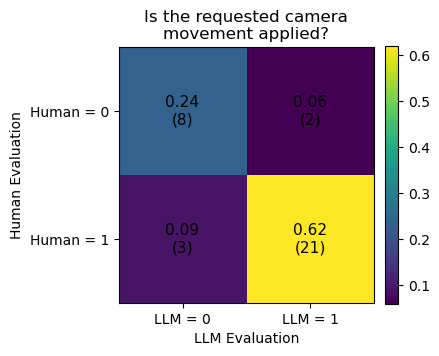

In [41]:
_ = plot_confusion_matrix_binary(
    human=list(chain.from_iterable(
        v.get("camera_eval", [])
        for v in dict_run_human_evals.values()
    )) , 
    llm=list(chain.from_iterable(
        v.get("camera_motion_done", [])
        for v in dict_run_gemini_evals.values()
    )),
    title="Is the requested camera\nmovement applied?"
)

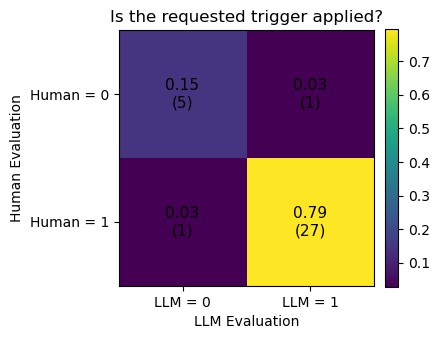

In [ ]:
_ = plot_confusion_matrix_binary(
    human=list(chain.from_iterable(
        v.get("trigger_eval", [])
        for v in dict_run_human_evals.values()
    )) , 
    llm=list(chain.from_iterable(
        v.get("trigger_applied", [])
        for v in dict_run_gemini_evals.values()
    )),
    title="Is the requested trigger applied?"
)